## Data Exploration & Cleaning

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/stzh.zwn_meldungen_p.csv") #importing the dataset and calling it "df"
df.head()


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14T15:16:15,2013-04-04T07:25:05,2013-04-12T07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14T15:17:57,2013-03-26T14:05:05,2013-04-12T08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,NaN,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15T09:14:16,2013-03-15T09:55:05,2013-04-12T08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15T09:17:15,2013-03-20T10:05:05,2013-04-12T08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15T10:36:53,2013-04-22T18:25:05,2013-04-23T13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


Now I have the data, I want to check to find where the types of incidents are listed(graffiti, vandalism, etc.), so:

In [2]:
df["service_name"].unique() #unique values in service_name

<ArrowStringArray>
[   'Strasse/Trottoir/Platz',       'Abfall/Sammelstelle',
   'Grünflächen/Spielplätze',         'Beleuchtung/Uhren',
                  'Graffiti', 'Signalisation/Lichtsignal',
         'Brunnen/Hydranten',                    'VBZ/ÖV',
                 'Allgemein',                'Schädlinge']
Length: 10, dtype: str

In [3]:
df["geometry"].head() #spatial geometry of point of each incident


0    POINT (2678968 1247548)
1    POINT (2680746 1249916)
2    POINT (2684605 1251431)
3    POINT (2681754 1250376)
4    POINT (2683094 1247762)
Name: geometry, dtype: str

Each incident has a geographical point location, likely using Swiss projection coordinates(e.g. Swiss CRS EPSG: 2056 projection). Also "dtype:str" signals that the data is stored in the form of text strings, thus will need to be transformed into spatial objects. This means transforming the dataframe into a GeoDataFrame, so that these text strings can be converted to real geographical locations and can be mapped or spatially joined.

In [4]:
df["service_name"].value_counts() #number of incidents for each event

service_name
Abfall/Sammelstelle          27445
Signalisation/Lichtsignal    10984
Strasse/Trottoir/Platz        9874
Grünflächen/Spielplätze       7254
Beleuchtung/Uhren             5414
Allgemein                     3977
Graffiti                      3780
VBZ/ÖV                        1886
Brunnen/Hydranten             1295
Schädlinge                     895
Name: count, dtype: int64

For this analysis, relevant columns are "requested_datetime", "service_name","geometry", and perhaps "title" and "status"

In [5]:
cleaned_df = df[["requested_datetime", "service_name","status","title","geometry"]] #creating the new dataset with
#relevant columns
cleaned_df.head()

,requested_datetime,service_name,status,title,geometry
0,2013-03-14T15:16:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,POINT (2678968 1247548)
1,2013-03-14T15:17:57,Strasse/Trottoir/Platz,fixed - council,Vermessungs,POINT (2680746 1249916)
2,2013-03-15T09:14:16,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,POINT (2684605 1251431)
3,2013-03-15T09:17:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,POINT (2681754 1250376)
4,2013-03-15T10:36:53,Abfall/Sammelstelle,fixed - council,Arbeitskist,POINT (2683094 1247762)


Now we have the dataframe with the relevant columns, we can convert the text strings into geometry objects using GeoPandas and Well-Known Text from Shapely, so:

In [6]:
import geopandas as gpd #for working with spatial data
from shapely import wkt #for converting text strings into spatial objects

Now we convert the geometry column values into spatial data, so:

In [7]:
cleaned_df["geometry"] = cleaned_df["geometry"].apply(wkt.loads) #this converts text strings into Shapely Points

The error shows how it was expected to be working with bytes or strings but it actually was Point data in the geometry column, signalling that the dataset is already close to a GeoDataFrame. Now we can create the GeoDataFrame, so:

In [8]:
zurich_gdf = gpd.GeoDataFrame(cleaned_df, geometry="geometry", crs="EPSG:2056") # added CRS so it is usable in other systems(according to error)

type(zurich_gdf)#verify that the type of the dataset is a GeoDataFrame

geopandas.geodataframe.GeoDataFrame

<Axes: >

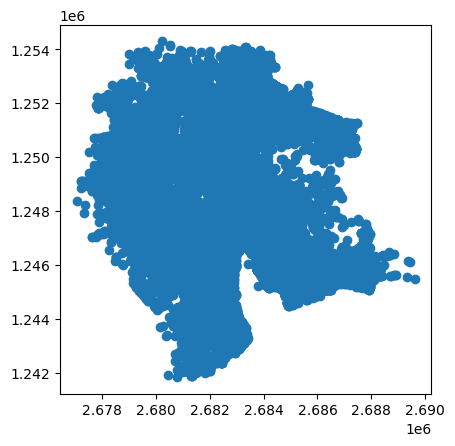

In [9]:
zurich_gdf.plot()#the data is working when we map it too

In [10]:
zurich_gdf.to_file("../data/processed/zurich_gdf.gpkg") #save the data to the folder to work with later

## Importing Zurich district polygons for spatial joining

Now that the GeoDataFrame of point data per incident has been created, it can be spatially joined to begin analyzing incidents across different areas of Zurich. Thus, we will therefor need polygon data of areas in Zurich for analysis. To do this, the "Statistische Quartier" geopackage was chosen which includes polygons of each quartier of Zurich. This will allow us to sort the incidents into their respective quartier. 

In [11]:
import geopandas as gpd

zurich_quartier_polygons = gpd.read_file("../data/raw/data.gpkg")

C:\Users\Emily Rose\miniconda3\envs\sds-env\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'data.gpkg': 'stzh.adm_statistische_quartiere_b_p' (default), 'stzh.adm_statistische_quartiere_v', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


Now lets inspect the dataset

In [12]:
zurich_quartier_polygons.head()

,objid,objectid,ori,hali,vali,name,kuerzel,geometry
0,1,1,0.0,1.0,2.0,Affoltern,111,POINT (2680575.711 1253034.933)
1,2,2,0.0,1.0,2.0,Seebach,119,POINT (2683071.957 1253148.375)
2,3,3,0.0,1.0,2.0,Saatlen,121,POINT (2684968.446 1251835.404)
3,4,4,0.0,1.0,2.0,Höngg,101,POINT (2679781.451 1251349.147)
4,5,5,0.0,1.0,2.0,Wipkingen,102,POINT (2681888.652 1250165.853)


In [13]:
zurich_quartier_polygons.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [14]:
zurich_quartier_polygons.geom_type.unique()

<ArrowStringArray>
['Point']
Length: 1, dtype: str

The CRS is indeed correct, as was listed on the dataset website. However, the dataset is listed as point data. The user warning after creating the zurich_quartier_polygons object indicates that there is more than one layer in the dataset, and this point layer is likely denoting the centroid of each quartier. Therefore, we must select the correct layer associated with the quartier polygons themselves. The likely layer is "stzh.adm_statistische_quartiere_map", so we select it when defining the object.

In [15]:
zurich_quartier_polygons = gpd.read_file("../data/raw/data.gpkg", layer="stzh.adm_statistische_quartiere_map")

Now we check the geometry type to see if its polygon data.

In [16]:
zurich_quartier_polygons.geom_type.unique()

<ArrowStringArray>
['Polygon']
Length: 1, dtype: str

Now we see it is the polygon layer, and we can plot it to see if it actually is the quartier polygons.

<Axes: >

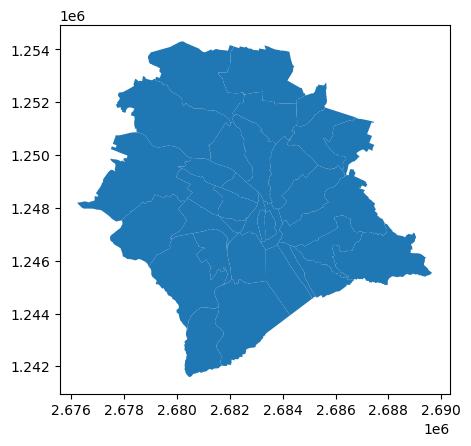

In [17]:
zurich_quartier_polygons.plot()

It is the correct layer, now we just double-check that both the incident point data and the polygon data are in the same CRS before spatially joining them.

In [18]:
zurich_gdf.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [19]:
zurich_quartier_polygons.crs

<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

They are both in the same CRS(EPSG: 2056) and are ready for spatial joining. This joint dataset will be the main foundational dataset for this analysis, so we must assure quality and give it a representative name. 

In [20]:
zurich_qi = gpd.sjoin( #spatially join the two datasets, "qi" is quartier incidents
    zurich_gdf, zurich_quartier_polygons,
    how = "left", #keep all the incident data points, even if some dont fall in a polygon
    predicate = "within" #describes to find which polygon each point falls within
) 

Now we check the joined dataframe to see if we have each incident(service_name) with an associated neighbourhood(qname).

In [21]:
zurich_qi.head()

,requested_datetime,service_name,status,title,geometry,index_right,objectid,qnr,qname,knr,kname
0,2013-03-14T15:16:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Asp,POINT (2678968 1247548),6.0,9.0,91.0,Albisrieden,9.0,Kreis 9
1,2013-03-14T15:17:57,Strasse/Trottoir/Platz,fixed - council,Vermessungs,POINT (2680746 1249916),10.0,19.0,101.0,Höngg,10.0,Kreis 10
2,2013-03-15T09:14:16,Strasse/Trottoir/Platz,fixed - council,Beim Trotto,POINT (2684605 1251431),26.0,26.0,121.0,Saatlen,12.0,Kreis 12
3,2013-03-15T09:17:15,Strasse/Trottoir/Platz,fixed - council,Auf dem Par,POINT (2681754 1250376),21.0,17.0,102.0,Wipkingen,10.0,Kreis 10
4,2013-03-15T10:36:53,Abfall/Sammelstelle,fixed - council,Arbeitskist,POINT (2683094 1247762),22.0,22.0,14.0,City,1.0,Kreis 1


We must also save this new joined dataset too.

In [22]:
zurich_qi.to_file("../data/processed/incidents_joined_quartiers.gpkg", driver = "GPKG")

Now that we have the spatially joined dataset with incidents organized into their associated quartier, we can begin working on answering questions about the data and creating outputs like maps and figures.

## Question 1: Which quartiers receive the highest number of total reports?

In order to answer this question, we must follow a structured workflow. First, we must count the total reports within each quartier and create a dataframe of this. Then we must merge this dataset with the polygon dataset. Finally, we will make a chloropleth map to visualize these results.

#### Step 1: Creating a dataframe of reports per quartier

We want to group all the incidents by quartier name and count them:

In [23]:
report_counts = zurich_qi.groupby("qname").size()

Then we want to convert this to a dataframe, as groupby().size() creates a series where quartier names are stored as indexes in the series and not a normal column. We therefor convert this to a dataframe so it can be easily merged with the polygon data. 

In [24]:
report_counts = report_counts.reset_index(name="report_count") #.reset_index() tells python to take this index and reset it back 
#to a column

Now we check the report_counts dataset

In [25]:
report_counts.head()

,qname,report_count
0,Affoltern,2427
1,Albisrieden,2035
2,Alt-Wiedikon,2517
3,Altstetten,4122
4,City,1742


Now that its properly formatted and ready to go, we can merge it with the quartier polygon dataset

In [26]:
quartier_report_counts = zurich_quartier_polygons.merge(
    report_counts,
    on="qname"
)

Check that the dataset is properly merged

In [27]:
quartier_report_counts.head()

,objectid,qnr,qname,knr,kname,geometry,report_count
0,1,73,Hirslanden,7,Kreis 7,"POLYGON ((2684457.034 1246514.804, 2684466.315...",1384
1,2,83,Weinegg,8,Kreis 8,"POLYGON ((2684457.383 1246512.719, 2684458.291...",810
2,3,82,Mühlebach,8,Kreis 8,"POLYGON ((2684269.913 1246566.796, 2684271.618...",912
3,4,81,Seefeld,8,Kreis 8,"POLYGON ((2683794.254 1246609.895, 2683802.117...",1283
4,7,41,Werd,4,Kreis 4,"POLYGON ((2682651.888 1247587.653, 2682650.697...",1576


We now have all the required columns for creating the chloropleth map (qname, geometry, report_count)

#### Step 2: Creating a chloropleth map of total reports per quartier

An appropriate way to visualize the numner of reports in each quartier and compare them is through a cholorpleth map. This assigns each total report number a color along a color scale, with darker shades typically representing high total reports and lighter shades representing low total reports. We can also assign a label to each quartier polygon, and then display a table underneath the map that tells us which label corresponds to which quartier, as well as provide the total reports for that quartier toThis can be created using functionalities of matplotlib.pyplot 

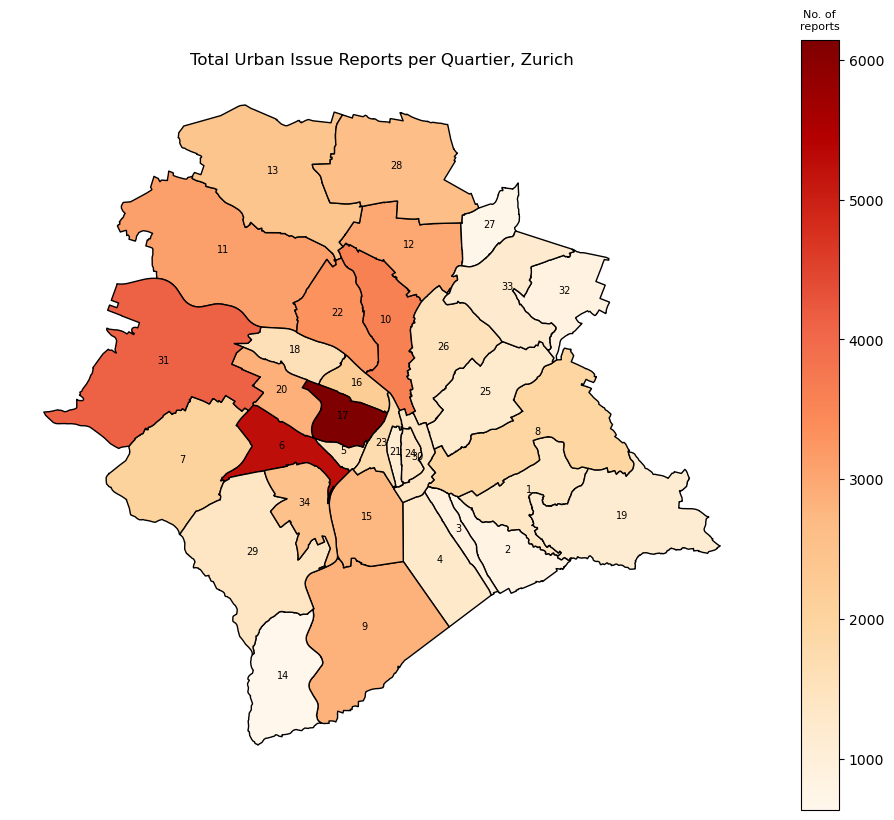

In [28]:
import matplotlib.pyplot as plt

#creating the label for each quartier
quartier_report_counts["label"] = range( 
    1,
    len(quartier_report_counts) + 1
)

#figure axis
fig, ax = plt.subplots(figsize=(12, 10)) 

quartier_report_counts.plot(
    column="report_count",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

#add a title to the scale bar
cbar = ax.get_figure().axes[1]  #when geopandas calls .plot(), it creates the main map axes and the colorbar axes
#the colorbar is the last axes object created. ax.get_figure() gets the figure that ax belongs to, .axes gets the list
#of all axes in that figure, and [1] grabs the last axis created
cbar.set_title("No. of\nreports", fontsize=8, pad=8)

#now we add label numbers to the centroid of each quartier polygon
for idx, row in quartier_report_counts.iterrows(): #tells python go through every row in the dataframe(idx is row number, rows contain values)
        centroid = row.geometry.centroid #find the centroid(middle point) of each polygon(quartier)
        ax.text( #draw text on the map at the coordinates of each polygon centroid
            centroid.x,
            centroid.y,
            str(row["label"]),#make row number the label of the polygon, str() used to convert labels from numbers to strings so matplotlib can process them
            ha="center", #horizontal alignment of the label is at the center, number on centroid point
            fontsize=7)

#add the title and remove unneccesary axes to reduce clutter
ax.set_title("Total Urban Issue Reports per Quartier, Zurich")
ax.axis("off")

plt.show()

The polygons are now labeled, but an issue arises with this approach. As observable in polygons 24 and 30, the label of polygon 30 bleeds into polygon 24. This is a common issues when dealing with C-shaped or long thin polygons like polygon 30, so we must label the polygons using a different method to deal with this. 

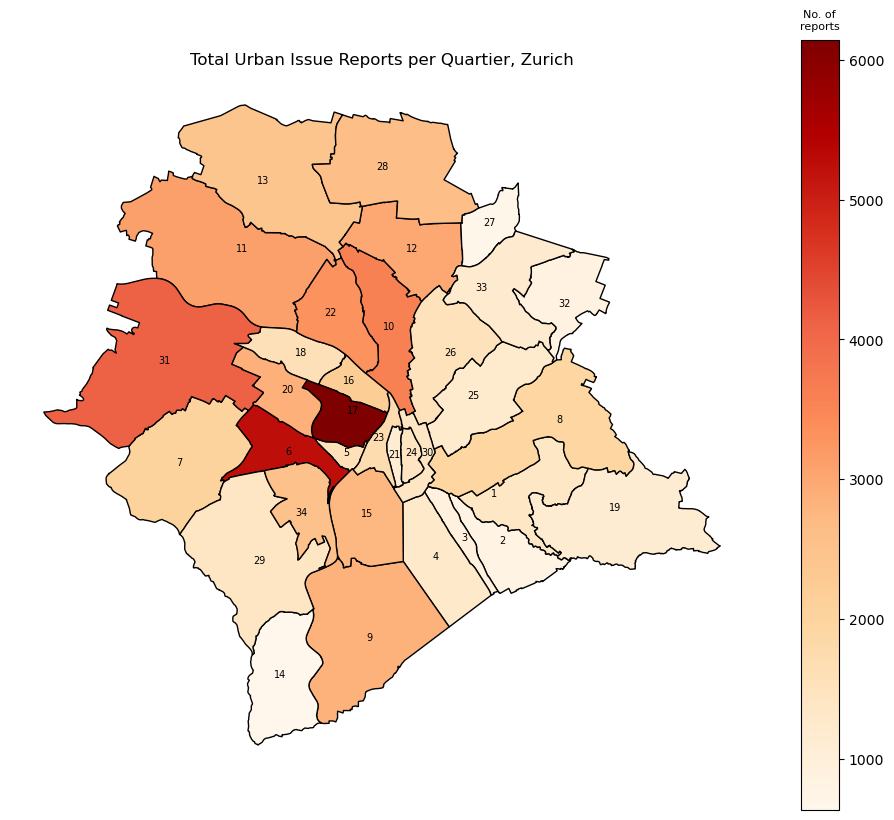

In [29]:
#creating the label for each quartier
quartier_report_counts["label"] = range( 
    1,
    len(quartier_report_counts) + 1
)

#figure axis
fig, ax = plt.subplots(figsize=(12, 10)) 

quartier_report_counts.plot(
    column="report_count",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

#add a title to the scale bar
cbar = ax.get_figure().axes[1]  #when geopandas calls .plot(), it creates the main map axes and the colorbar axes
#the colorbar is the last axes object created. ax.get_figure() gets the figure that ax belongs to, .axes gets the list
#of all axes in that figure, and [1] grabs the last axis created
cbar.set_title("No. of\nreports", fontsize=8, pad=8)

#now we add label numbers to the centroid of each quartier polygon
for idx, row in quartier_report_counts.iterrows(): #tells python go through every row in the dataframe(idx is row number, rows contain values)
        middle_point = row.geometry.representative_point() #guarantees the point is inside the polygon, specifically designed for such sitations
        ax.text( #draw text on the map at the coordinates of each polygon centroid
            middle_point.x,#now the representative point coordinates rather than the centroid coordinates
            middle_point.y,
            str(row["label"]),#make row number the label of the polygon, str() used to convert labels from numbers to strings so matplotlib can process them
            ha="center", #horizontal alignment of the label is at the center, number on centroid point
            fontsize=7)

#add the title and remove unneccesary axes to reduce clutter
ax.set_title("Total Urban Issue Reports per Quartier, Zurich")
ax.axis("off")

plt.show()

Now that the map is looking better with all the polygon labels within their associated polygon, we can create a lookup table to display below the map. This will include information on each label number's corresponding quartier, and also the total number of reports per quartier.

In [30]:
quartier_label_table = quartier_report_counts[
    ["label", "qname", "report_count"]#selects the relevant columns from quartier_report_counts for the table
    ].sort_values("label")#sort the table by their label values rather than their index values

quartier_label_table.head()

,label,qname,report_count
0,1,Hirslanden,1384
1,2,Weinegg,810
2,3,Mühlebach,912
3,4,Seefeld,1283
4,5,Werd,1576


Now that we have the table with the label and its corresponding quartier and report_count value, we start creating the annotation we want to show beneath the map. 

In [31]:
annotation_entries_chloropleth = [#creating the annotation string
    f"{row['label']} - {row['qname']} - {row['report_count']} reports"#entries will be displayed as e.g. 1 - Hirslanden - 1384 reports
    for _, row in quartier_label_table.iterrows()
]

with the annotation created, we need to define how many entries we want per line under the map, so that it doesnt just show along one huge line and minimize the map as a result. To do this, we define the amount of entries we want per line and then create the final annotation from this

In [32]:
entries_per_line_chloropleth = 6

lines =[] #create an empty list, this will hold each line of text of the annotation

for i in range(0, len(annotation_entries_chloropleth), entries_per_line_chloropleth): #loops through entries in steps of 6
    #i takes the index values 0, 6, 12, etc. of annotation_entries_chloropleth, processing them in groups of 6
    chunk = annotation_entries_chloropleth[i:i + entries_per_line_chloropleth]#this slices out 6 entries from the list
    #for example, [0:6] slices out the first 6 quartiers, [6:12] slices out the next 6 quartiers, etc.
    lines.append("  |  ".join(chunk))#joins the 6 entries in a single string seperate by |, and adds these to the lines list
#each element of the lines list is therefore one full row of the annotation text
annotation_chloropleth = "\n".join(lines)#joins all the annotation lines together, with "\n".join(lines) creating a new line between each element

With the annotation created, we can add it below our map

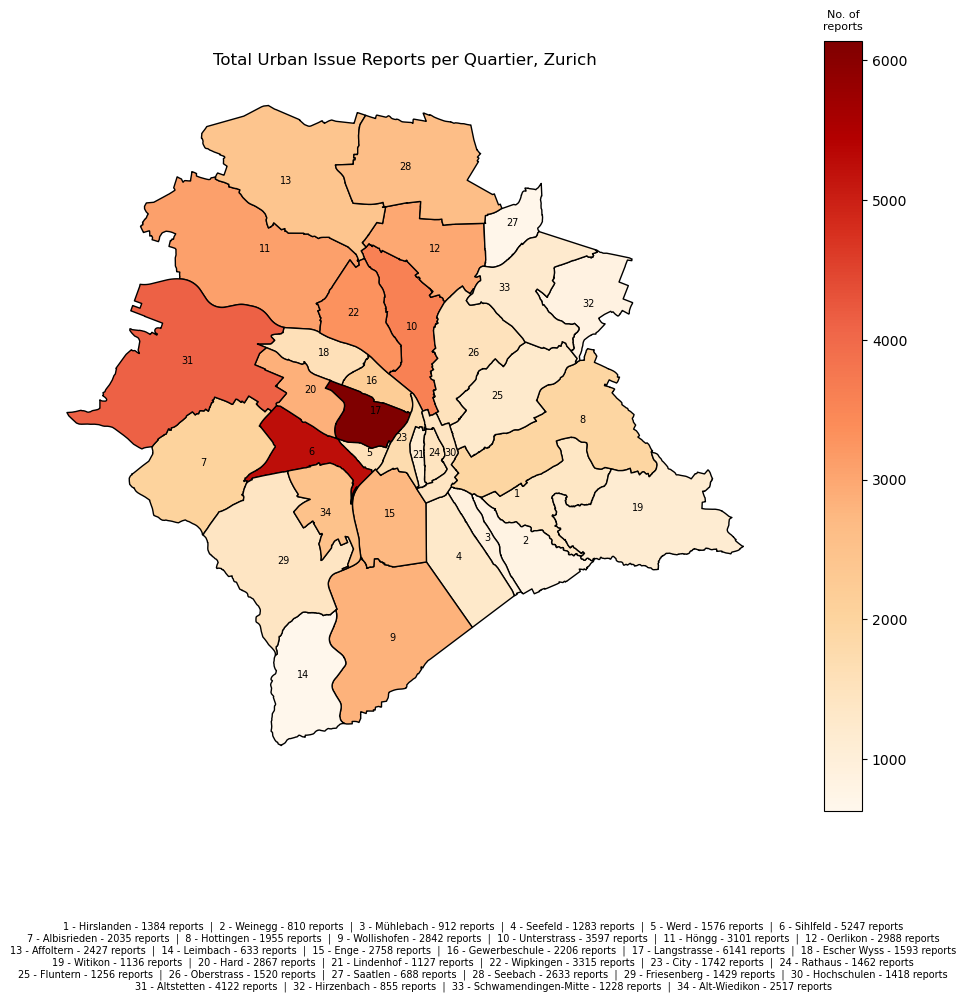

In [33]:
#creating the label for each quartier
quartier_report_counts["label"] = range( 
    1,
    len(quartier_report_counts) + 1
)

#figure axis
fig, ax = plt.subplots(figsize=(12, 10)) 

quartier_report_counts.plot(
    column="report_count",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    ax=ax
)

#add a title to the scale bar
cbar = ax.get_figure().axes[1]  #when geopandas calls .plot(), it creates the main map axes and the colorbar axes
#the colorbar is the last axes object created. ax.get_figure() gets the figure that ax belongs to, .axes gets the list
#of all axes in that figure, and [1] grabs the last axis created
cbar.set_title("No. of\nreports", fontsize=8, pad=8)

#now we add label numbers to the centroid of each quartier polygon
for idx, row in quartier_report_counts.iterrows(): #tells python go through every row in the dataframe(idx is row number, rows contain values)
        middle_point = row.geometry.representative_point() #guarantees the point is inside the polygon, specifically designed for such sitations
        ax.text( #draw text on the map at the coordinates of each polygon centroid
            middle_point.x,#now the representative point coordinates rather than the centroid coordinates
            middle_point.y,
            str(row["label"]),#make row number the label of the polygon, str() used to convert labels from numbers to strings so matplotlib can process them
            ha="center", #horizontal alignment of the label is at the center, number on centroid point
            fontsize=7)

#add the annotation below the map
fig.text(
    0.5, #centered on x-axis
    -0.0005, #just below the y-axis
    annotation_chloropleth, 
    ha="center",
    va="top",
    fontsize=7,
    transform=fig.transFigure
)

#add the title and remove unneccesary axes to reduce clutter
ax.set_title("Total Urban Issue Reports per Quartier, Zurich")
ax.axis("off")



plt.show()

Now that we have created the final map, we can save it to the outputs folder.

In [34]:
fig.savefig(
    "../outputs/total_reports_per_quartier_chloropleth.png", #save it in outputs
    dpi=300,
    bbox_inches="tight")#expand image to fit all content in the figure, so that none is cut off
    

## Question 2: Which categories of reports are most common in Zurich? 

For this question, the plan is to create 2 outputs; a bar chart visualization of citywide urban issue category frequency, and a map showing the dominant issue type in each quartier. 

#### Step 1: Translate all the urban issue types to English

First, we will translate the urban issue categories from the service_name column in the zurich_qi dataset to english. To do this, we will keep the original column but add a new column for the english translations. So first we will list all the service names.

In [39]:
zurich_qi["service_name"].value_counts()

service_name
Abfall/Sammelstelle          27445
Signalisation/Lichtsignal    10984
Strasse/Trottoir/Platz        9874
Grünflächen/Spielplätze       7254
Beleuchtung/Uhren             5414
Allgemein                     3977
Graffiti                      3780
VBZ/ÖV                        1886
Brunnen/Hydranten             1295
Schädlinge                     895
Name: count, dtype: int64

Now we can see we have 10 different urban issue categories we need to translate.

In [44]:
#create the translations:
translations = {
    "Abfall/Sammelstelle":"Waste/Collection Point",
    "Signalisation/Lichtsignal":"Light signals/Traffic Signals/Signs",
    "Strasse/Trottoir/Platz":"Street/Pavement/Square",
    "Grünflächen/Spielplätze":"Green Spaces/Playground",
    "Beleuchtung/Uhren":"Lights/Clocks",
    "Allgemein":"General",
    "Graffiti":"Graffiti",
    "VBZ/ÖV":"Public Transport",
    "Brunnen/Hydranten":"Fountains/Fire Hydrants",
    "Schädlinge":"Pests"
}

Then we add English category column to zurich_qi.

In [46]:
zurich_qi["service_name_english"] = (
    zurich_qi["service_name"].map(translations))
#.map() tells python to replace each German category from service_name with the English ones from translations

zurich_qi.head()

zurich_qi["service_name_english"].value_counts()

service_name_english
Waste/Collection Point                 27445
Light signals/Traffic Signals/Signs    10984
Street/Pavement/Square                  9874
Green Spaces/Playground                 7254
Lights/Clocks                           5414
General                                 3977
Graffiti                                3780
Public Transport                        1886
Fountains/Fire Hydrants                 1295
Pests                                    895
Name: count, dtype: int64